# DNA-DetectLLM — Replication & Ablation Analysis

**IE 663: Advanced Topics in Deep Learning | IIT Bombay**  
**Team Eternal — Tanmay Mandaliya (22B1037)**

---

> *DNA-DetectLLM: Unveiling AI-Generated Text via a DNA-Inspired Mutation-Repair Paradigm* (NeurIPS 2025)

We use the **paper's official codebase** (`dna_detectllm/`) with a minimal modification for 4-bit NF4 quantization on Kaggle T4 GPUs.

## Part 1 — Replication
- **Table 1**: Human vs AI detection (arXiv, XSum × GPT-4, Claude, Gemini)
- **Table 2**: Benchmark evaluation (M4, DetectRL, RealDet)
- **Table 10**: Repair order comparison

## Part 2 — Analysis
- Component ablation (PPL-only → σ-only → Sum-PPL → Full)
- Temperature sensitivity
- Short text robustness

**Hardware**: Kaggle T4×2, 4-bit NF4 quantization

In [1]:
!pip install transformers accelerate bitsandbytes -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.9 MB/s eta 0:00:00:00:0100:01


In [2]:
import shutil

src = "/kaggle/input/datasets/pramukhswami/dna-detectllm-1/dna_detectllm"
shutil.copytree(src, "dna_detectllm", dirs_exist_ok=True)

!ls dna_detectllm/

detector.py  __init__.py  metrics.py  utils.py


In [3]:
import os
os.environ["HF_TOKEN"] = "YOUR_HF_TOKEN_HERE"

import torch
import torch.nn.functional as F
import numpy as np
import json, time, warnings
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

n_gpus = torch.cuda.device_count()
print(f"PyTorch {torch.__version__} | GPUs: {n_gpus}")
for i in range(n_gpus):
    mem = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)} ({mem:.1f} GB)")

PyTorch 2.9.0+cu126 | GPUs: 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)


## Setup — Download Datasets & Load Models

In [4]:
!mkdir -p data

BASE = "https://raw.githubusercontent.com/Xiaoweizhu57/DNA-DetectLLM/main/Data"

# human texts
!wget -q -O data/arxiv_human.json       "{BASE}/Collected%20data/arxiv_human.json"
!wget -q -O data/xsum_human.json        "{BASE}/Collected%20data/xsum_human.json"
!wget -q -O data/wp_human.json          "{BASE}/Collected%20data/wp_human.json"

# AI-generated texts
!wget -q -O data/gpt4_machine.json      "{BASE}/Collected%20data/GPT4_machine_test.json"
!wget -q -O data/claude_machine.json    "{BASE}/Collected%20data/Claude_machine_test.json"
!wget -q -O data/gemini_machine.json    "{BASE}/Collected%20data/Gemini_machine_test.json"

# benchmark datasets
!wget -q -O data/m4_human.json          "{BASE}/M4/M4_human_test.json"
!wget -q -O data/m4_machine.json        "{BASE}/M4/M4_machine_test.json"
!wget -q -O data/detectrl_human.json    "{BASE}/DetectRL/DetectRL_multidomain_human_test.json"
!wget -q -O data/detectrl_machine.json  "{BASE}/DetectRL/DetectRL_multidomain_machine_test.json"
!wget -q -O data/realdet_human.json     "{BASE}/RealDet/RealDet_human_test.json"
!wget -q -O data/realdet_machine.json   "{BASE}/RealDet/RealDet_machine_test.json"

print("Downloaded files:")
!ls -lh data/

Downloaded files:
total 39M
-rw-r--r-- 1 root root 1.9M Mar  7 06:28 arxiv_human.json
-rw-r--r-- 1 root root 5.7M Mar  7 06:28 claude_machine.json
-rw-r--r-- 1 root root 1.5M Mar  7 06:28 detectrl_human.json
-rw-r--r-- 1 root root 975K Mar  7 06:28 detectrl_machine.json
-rw-r--r-- 1 root root 6.7M Mar  7 06:28 gemini_machine.json
-rw-r--r-- 1 root root 7.8M Mar  7 06:28 gpt4_machine.json
-rw-r--r-- 1 root root 2.7M Mar  7 06:28 m4_human.json
-rw-r--r-- 1 root root 1.7M Mar  7 06:28 m4_machine.json
-rw-r--r-- 1 root root 1.3M Mar  7 06:28 realdet_human.json
-rw-r--r-- 1 root root 1.2M Mar  7 06:28 realdet_machine.json
-rw-r--r-- 1 root root 4.4M Mar  7 06:28 wp_human.json
-rw-r--r-- 1 root root 3.5M Mar  7 06:28 xsum_human.json


In [5]:
def load_texts(path):
    """Load text samples from the paper's JSON files."""
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, dict):
        for key in ["human_text", "machine_text", "text", "texts"]:
            if key in data:
                return data[key]
        first_key = list(data.keys())[0]
        if isinstance(data[first_key], list):
            return data[first_key]
    if isinstance(data, list):
        if isinstance(data[0], str):
            return data
        if isinstance(data[0], dict) and "text" in data[0]:
            return [d["text"] for d in data]
    raise ValueError(f"Cannot parse {path}")

for name, path in [("arXiv human", "data/arxiv_human.json"),
                    ("GPT-4 machine", "data/gpt4_machine.json"),
                    ("XSum human", "data/xsum_human.json")]:
    texts = load_texts(path)
    avg_words = np.mean([len(t.split()) for t in texts[:50]])
    print(f"{name}: {len(texts)} samples, avg {avg_words:.0f} words")

arXiv human: 1600 samples, avg 175 words
GPT-4 machine: 4800 samples, avg 320 words
XSum human: 1600 samples, avg 398 words


### Load Models via Paper's Codebase

We use `dna_detectllm.DetectLLM` from the paper's official code. The only change to `detector.py` is swapping bfloat16 loading for 4-bit NF4 quantization so it fits on T4 GPUs (~4.5 GB per model instead of ~14 GB).

We also import the individual metric functions for ablation experiments later.

In [6]:
from dna_detectllm import DetectLLM
from dna_detectllm.metrics import perplexity, sum_perplexity, entropy
from dna_detectllm.detector import DEVICE_1, DEVICE_2

detector = DetectLLM(
    observer_name_or_path="tiiuae/falcon-7b",
    performer_name_or_path="tiiuae/falcon-7b-instruct",
    use_4bit=True,
    max_token_observed=512,
    mode="accuracy",
)

print(f"GPU 0 mem: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")
print(f"GPU 1 mem: {torch.cuda.memory_allocated(1)/1e9:.1f} GB")
print("Ready.")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

GPU 0 mem: 4.9 GB
GPU 1 mem: 4.9 GB
Ready.


In [7]:
def score_texts(texts, desc="Scoring"):
    """Score a list of texts using the paper's compute_score function"""
    scores = []
    for text in tqdm(texts, desc=desc):
        try:
            s = detector.compute_score(text)
            scores.append(s[0] if isinstance(s, list) else s)
        except:
            scores.append(float('nan'))
    return scores


def evaluate(human_scores, ai_scores):
    """AUROC and best F1"""
    h = [s for s in human_scores if not np.isnan(s)]
    a = [s for s in ai_scores if not np.isnan(s)]
    labels = [1]*len(h) + [0]*len(a)
    all_scores = h + a
    auroc = roc_auc_score(labels, all_scores)
    prec, rec, _ = precision_recall_curve(labels, all_scores)
    f1 = (2 * prec * rec / (prec + rec + 1e-8)).max()
    return auroc, f1


def run_experiment(human_path, ai_path, name, n=200):
    """Full experiment pipeline: load, score and evaluate"""
    h_texts = load_texts(human_path)[:n]
    a_texts = load_texts(ai_path)[:n]
    print(f"\n--- {name} ---")
    print(f"Human: {len(h_texts)} | AI: {len(a_texts)}")

    t0 = time.time()
    h_scores = score_texts(h_texts, desc=f"{name} [Human]")
    a_scores = score_texts(a_texts, desc=f"{name} [AI]")
    elapsed = time.time() - t0

    auroc, f1 = evaluate(h_scores, a_scores)
    speed = elapsed / (len(h_texts) + len(a_texts))

    print(f"AUROC: {auroc*100:.2f}% | F1: {f1*100:.2f}% | {speed:.2f}s/sample")
    return {"name": name, "auroc": auroc, "f1": f1, "speed": speed,
            "h_scores": h_scores, "a_scores": a_scores}

# quick sanity check
test_score = detector.compute_score("The quick brown fox jumps over the lazy dog.")
print(f"Test score: {test_score}")

Test score: [0.522292971611023]


---
# Part 1 — Replication

## Table 1 — Collected Data

Human-written texts from arXiv and XSum vs AI-generated from GPT-4 Turbo, Claude-3.7 Sonnet, Gemini-2.0 Flash.  
Paper reports average AUROC of **98.30%**.

In [8]:
N = 200

table1_configs = [
    ("data/arxiv_human.json", "data/gpt4_machine.json",   "arXiv vs GPT-4"),
    ("data/arxiv_human.json", "data/claude_machine.json", "arXiv vs Claude"),
    ("data/arxiv_human.json", "data/gemini_machine.json", "arXiv vs Gemini"),
    ("data/xsum_human.json",  "data/gpt4_machine.json",   "XSum vs GPT-4"),
    ("data/xsum_human.json",  "data/claude_machine.json", "XSum vs Claude"),
]

table1_results = []
for h_path, a_path, name in table1_configs:
    r = run_experiment(h_path, a_path, name, n=N)
    table1_results.append(r)


--- arXiv vs GPT-4 ---
Human: 200 | AI: 200


arXiv vs GPT-4 [AI]: 100%|██████████| 200/200 [07:00<00:00,  2.10s/it]


AUROC: 97.94% | F1: 93.40% | 1.80s/sample

--- arXiv vs Claude ---
Human: 200 | AI: 200


arXiv vs Claude [AI]: 100%|██████████| 200/200 [04:57<00:00,  1.49s/it]


AUROC: 94.56% | F1: 89.38% | 1.55s/sample

--- arXiv vs Gemini ---
Human: 200 | AI: 200


...

AUROC: 94.08% | F1: 90.87% | 1.62s/sample

--- XSum vs GPT-4 ---
Human: 200 | AI: 200


XSum vs GPT-4 [AI]: 100%|██████████| 200/200 [06:59<00:00,  2.10s/it]


AUROC: 99.61% | F1: 97.54% | 2.02s/sample

--- XSum vs Claude ---
Human: 200 | AI: 200


XSum vs Claude [AI]: 100%|██████████| 200/200 [04:57<00:00,  1.49s/it]

AUROC: 97.27% | F1: 93.40% | 1.72s/sample


In [9]:
print("TABLE 1 — Collected Data Results")
print(f"{'Experiment':<25} {'AUROC':>8} {'F1':>8} {'s/sample':>10}")
print("-" * 55)
for r in table1_results:
    print(f"{r['name']:<25} {r['auroc']*100:>7.2f}% {r['f1']*100:>7.2f}% {r['speed']:>9.2f}s")

avg_auroc = np.mean([r['auroc'] for r in table1_results])
avg_f1 = np.mean([r['f1'] for r in table1_results])
print(f"\nAverage AUROC: {avg_auroc*100:.2f}% | Average F1: {avg_f1*100:.2f}%")
print(f"Paper reports: 98.30% avg AUROC")

TABLE 1 — Collected Data Results
Experiment                   AUROC       F1   s/sample
-------------------------------------------------------
arXiv vs GPT-4              97.94%   93.40%      1.80s
arXiv vs Claude             94.56%   89.38%      1.55s
arXiv vs Gemini             94.08%   90.87%      1.62s
XSum vs GPT-4               99.61%   97.54%      2.02s
XSum vs Claude              97.27%   93.40%      1.72s

Average AUROC: 96.69% | Average F1: 92.92%
Paper reports: 98.30% avg AUROC


## Table 2 — Benchmark Datasets

M4 (multi-generator), DetectRL (multi-domain), RealDet.  
Paper reports average AUROC **90.86%**, F1 **87.02%**.

In [10]:
table2_configs = [
    ("data/m4_human.json",       "data/m4_machine.json",       "M4"),
    ("data/detectrl_human.json", "data/detectrl_machine.json", "DetectRL"),
    ("data/realdet_human.json",  "data/realdet_machine.json",  "RealDet"),
]

table2_results = []
for h_path, a_path, name in table2_configs:
    r = run_experiment(h_path, a_path, name, n=N)
    table2_results.append(r)


--- M4 ---
Human: 200 | AI: 200


M4 [AI]: 100%|██████████| 200/200 [06:07<00:00,  1.84s/it]


AUROC: 90.88% | F1: 89.25% | 1.86s/sample

--- DetectRL ---
Human: 200 | AI: 200


DetectRL [AI]: 100%|██████████| 200/200 [05:19<00:00,  1.60s/it]


AUROC: 90.09% | F1: 87.58% | 1.74s/sample

--- RealDet ---
Human: 200 | AI: 200


RealDet [AI]: 100%|██████████| 200/200 [03:16<00:00,  1.02it/s]

AUROC: 91.45% | F1: 85.78% | 0.97s/sample


In [11]:
print("TABLE 2 — Benchmark Results")
print(f"{'Benchmark':<25} {'AUROC':>8} {'F1':>8} {'s/sample':>10}")
print("-" * 55)
for r in table2_results:
    print(f"{r['name']:<25} {r['auroc']*100:>7.2f}% {r['f1']*100:>7.2f}% {r['speed']:>9.2f}s")

avg_auroc = np.mean([r['auroc'] for r in table2_results])
avg_f1 = np.mean([r['f1'] for r in table2_results])
print(f"\nAverage AUROC: {avg_auroc*100:.2f}% | Average F1: {avg_f1*100:.2f}%")
print(f"Paper reports: 90.86% avg AUROC, 87.02% avg F1")

TABLE 2 — Benchmark Results
Benchmark                    AUROC       F1   s/sample
-------------------------------------------------------
M4                          90.88%   89.25%      1.86s
DetectRL                    90.09%   87.58%      1.74s
RealDet                     91.45%   85.78%      0.97s

Average AUROC: 90.81% | Average F1: 87.54%
Paper reports: 90.86% avg AUROC, 87.02% avg F1


## Table 10 — Repair Order Comparison

The paper proves averaging over all $T!$ random repair orderings converges to a closed-form. We verify different iterative orders give similar AUROC and that the simplified formula is much faster.

Uses the paper's `compute_score_iterative()` which calls `auc_perplexity()` internally.

In [12]:
N_REPAIR = 30

h_repair = load_texts("data/arxiv_human.json")[:N_REPAIR]
a_repair = load_texts("data/gpt4_machine.json")[:N_REPAIR]
all_repair = h_repair + a_repair

repair_results = {}

# simplified closed-form
print("Running simplified (closed-form)...")
t0 = time.time()
scores_simple = []
for t in tqdm(all_repair, desc="Simplified"):
    try:
        s = detector.compute_score(t)
        scores_simple.append(s[0] if isinstance(s, list) else s)
    except:
        scores_simple.append(float('nan'))
repair_results["Simplified"] = {"scores": scores_simple, "time": time.time() - t0}

# iterative orders
for order_name, order_key in [("High-to-low", "h2l"), ("Low-to-high", "l2h"), ("Sequential", "s")]:
    print(f"\nRunning {order_name} (iterative)...")
    t0 = time.time()
    scores_iter = []
    for t in tqdm(all_repair, desc=order_name):
        try:
            s = detector.compute_score_iterative(t, repair_order=order_key)
            scores_iter.append(s if isinstance(s, (int, float)) else s[0])
        except:
            scores_iter.append(float('nan'))
    repair_results[order_name] = {"scores": scores_iter, "time": time.time() - t0}

Running simplified (closed-form)...


Simplified: 100%|██████████| 60/60 [01:50<00:00,  1.84s/it]



Running High-to-low (iterative)...


High-to-low: 100%|██████████| 60/60 [13:21<00:00, 13.37s/it]



Running Low-to-high (iterative)...


Low-to-high: 100%|██████████| 60/60 [13:22<00:00, 13.38s/it]



Running Sequential (iterative)...


Sequential: 100%|██████████| 60/60 [13:22<00:00, 13.38s/it]


In [ ]:
print("TABLE 10 — Repair Order Comparison")
print(f"{'Strategy':<20} {'AUROC':>8} {'F1':>8} {'Time':>8} {'Speedup':>8}")
print("-" * 55)

t_base = repair_results["Simplified"]["time"]
for name in ["Simplified", "High-to-low", "Low-to-high", "Sequential"]:
    r = repair_results[name]
    h_sc = [s for s in r["scores"][:N_REPAIR] if not np.isnan(s)]
    a_sc = [s for s in r["scores"][N_REPAIR:] if not np.isnan(s)]
    if h_sc and a_sc:
        auroc, f1 = evaluate(h_sc, a_sc)
    else:
        auroc, f1 = 0, 0
    speedup = r["time"] / t_base if t_base > 0 else 1
    tag = " <-- default" if name == "Simplified" else ""
    print(f"{name:<20} {auroc*100:>7.2f}% {f1*100:>7.2f}% {r['time']:>7.1f}s {speedup:>7.1f}x{tag}")

TABLE 10 — Repair Order Comparison
Strategy                AUROC       F1     Time  Speedup
-------------------------------------------------------
Simplified             97.44%   96.67%   110.2s     1.0x <-- default
High-to-low            96.78%   95.08%   802.0s     7.3x
Low-to-high            96.78%   95.08%   802.6s     7.3x
Sequential             96.78%   95.08%   802.5s     7.3x

Paper reports simplified is ~18x faster with comparable AUROC


## Replication Visualizations

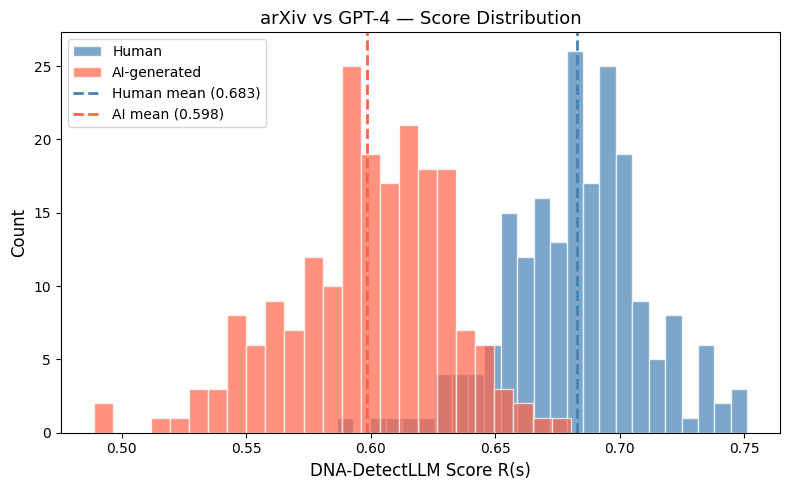

In [14]:
# score distribution
r = table1_results[0]
h_valid = [s for s in r['h_scores'] if not np.isnan(s)]
a_valid = [s for s in r['a_scores'] if not np.isnan(s)]

plt.figure(figsize=(8, 5))
plt.hist(h_valid, bins=25, alpha=0.7, label='Human', color='steelblue', edgecolor='white')
plt.hist(a_valid, bins=25, alpha=0.7, label='AI-generated', color='tomato', edgecolor='white')
plt.axvline(np.mean(h_valid), color='steelblue', ls='--', lw=2, label=f'Human mean ({np.mean(h_valid):.3f})')
plt.axvline(np.mean(a_valid), color='tomato', ls='--', lw=2, label=f'AI mean ({np.mean(a_valid):.3f})')
plt.xlabel('DNA-DetectLLM Score R(s)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title(f'{r["name"]} — Score Distribution', fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

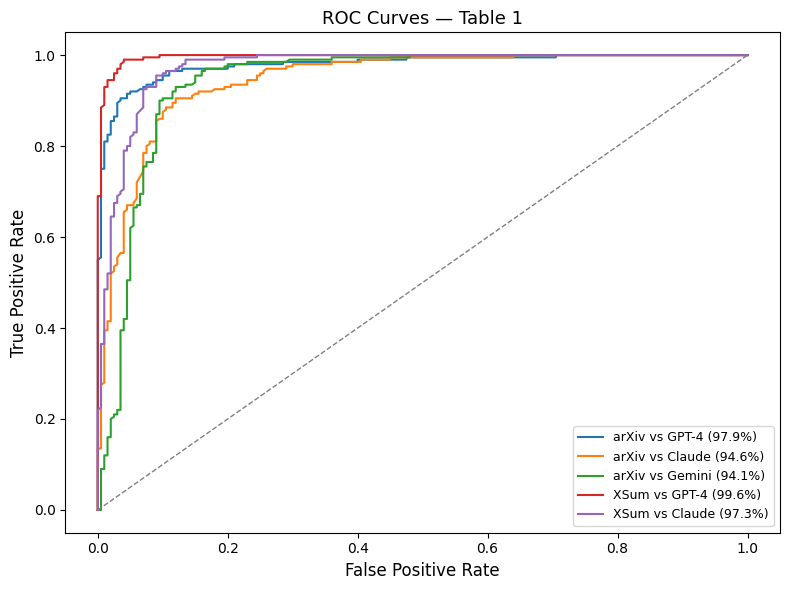

In [15]:
# ROC curves
plt.figure(figsize=(8, 6))
for r in table1_results:
    h_v = [s for s in r['h_scores'] if not np.isnan(s)]
    a_v = [s for s in r['a_scores'] if not np.isnan(s)]
    fpr, tpr, _ = roc_curve([1]*len(h_v) + [0]*len(a_v), h_v + a_v)
    plt.plot(fpr, tpr, lw=1.5, label=f"{r['name']} ({r['auroc']*100:.1f}%)")
plt.plot([0, 1], [0, 1], '--', color='gray', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Table 1', fontsize=13)
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc.png', dpi=150, bbox_inches='tight')
plt.show()

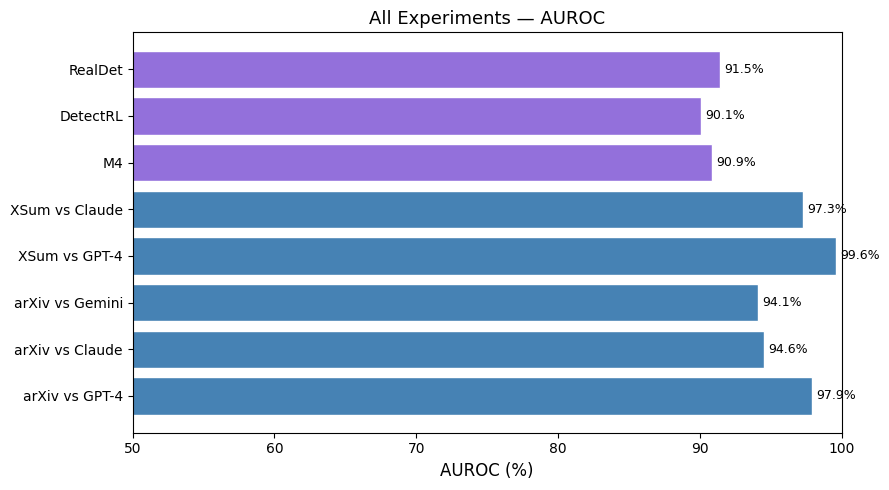

In [16]:
# AUROC bar chart
all_r = table1_results + table2_results
names = [r['name'] for r in all_r]
aurocs = [r['auroc']*100 for r in all_r]
colors = ['steelblue']*len(table1_results) + ['mediumpurple']*len(table2_results)

plt.figure(figsize=(9, 5))
plt.barh(names, aurocs, color=colors, edgecolor='white')
plt.xlabel('AUROC (%)', fontsize=12)
plt.title('All Experiments — AUROC', fontsize=13)
plt.xlim(50, 100)
for i, v in enumerate(aurocs):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_auroc_all.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 2 — Ablation Analysis

## Component Ablation

| Variant | Formula | What it tests |
|---|---|---|
| PPL-only | $\text{PPL}(s)$ | Raw perplexity baseline |
| $\sigma(s)$ only | $\text{PPL}(s) / \text{X-PPL}(s)$ | Binoculars-style ratio, no mutation term |
| Sum-PPL (no norm) | $\text{PPL}(s) + \text{PPL}(\hat{s}\mid s)$ | Mutation signal without normalization |
| Full DNA-DetectLLM | $\frac{\text{PPL}(s) + \text{PPL}(\hat{s}\mid s)}{2 \times \text{X-PPL}(s)}$ | Complete method |

We use the paper's `perplexity()`, `sum_perplexity()`, and `entropy()` from `metrics.py`.

In [17]:
# helper to get logits once and reuse for all variants
@torch.inference_mode()
def get_logits_and_encodings(text):
    encodings = detector._tokenize([text])
    obs_logits = detector.observer_model(**encodings.to(DEVICE_1)).logits
    perf_logits = detector.performer_model(**encodings.to(DEVICE_2)).logits
    return encodings.to(DEVICE_1), obs_logits.to(DEVICE_1), perf_logits.to(DEVICE_1)


@torch.inference_mode()
def compute_all_variants(text):
    """All 4 scoring variants in one forward pass using paper's metric functions."""
    encodings, obs_logits, perf_logits = get_logits_and_encodings(text)
    pad_id = detector.tokenizer.pad_token_id

    ppl_val = perplexity(encodings, perf_logits)
    sum_ppl_val = sum_perplexity(encodings, perf_logits)
    x_ppl_val = entropy(obs_logits, perf_logits, encodings, pad_id)

    return {
        "ppl_only":    float(ppl_val[0]),
        "sigma_only":  float(ppl_val[0] / x_ppl_val[0]),
        "sum_ppl_raw": float(sum_ppl_val[0]),
        "dna_full":    float(sum_ppl_val[0] / (2 * x_ppl_val[0])),
    }

def eval_scores(scores, n_human):
    h = [s for s in scores[:n_human] if not np.isnan(s)]
    a = [s for s in scores[n_human:] if not np.isnan(s)]
    labels = [1]*len(h) + [0]*len(a)
    auroc = roc_auc_score(labels, h + a)
    prec, rec, _ = precision_recall_curve(labels, h + a)
    f1 = (2 * prec * rec / (prec + rec + 1e-8)).max()
    return auroc, f1

In [18]:
N_ABL = 150

h_abl = load_texts("data/arxiv_human.json")[:N_ABL]
a_abl = load_texts("data/gpt4_machine.json")[:N_ABL]
all_abl = h_abl + a_abl

print(f"Scoring {len(all_abl)} texts (all 4 variants per forward pass)...\n")

variant_scores = {k: [] for k in ["ppl_only", "sigma_only", "sum_ppl_raw", "dna_full"]}

for text in tqdm(all_abl, desc="Ablation"):
    try:
        result = compute_all_variants(text)
        for k in variant_scores:
            variant_scores[k].append(result[k])
    except:
        for k in variant_scores:
            variant_scores[k].append(float('nan'))

print("Done.")

Scoring 300 texts (all 4 variants per forward pass)...



Ablation: 100%|██████████| 300/300 [09:39<00:00,  1.93s/it]

Done.


In [19]:
variant_names = {
    "ppl_only":    "PPL only",
    "sigma_only":  "σ(s) only (Binoculars-like)",
    "sum_ppl_raw": "Sum-PPL (no normalization)",
    "dna_full":    "Full DNA-DetectLLM",
}

print("COMPONENT ABLATION — arXiv vs GPT-4")
print(f"{'Variant':<35} {'AUROC':>8} {'F1':>8}")
print("-" * 55)

ablation_results = {}
for key in ["ppl_only", "sigma_only", "sum_ppl_raw", "dna_full"]:
    auroc, f1 = eval_scores(variant_scores[key], N_ABL)
    ablation_results[key] = {"auroc": auroc, "f1": f1}
    marker = " ***" if key == "dna_full" else ""
    print(f"{variant_names[key]:<35} {auroc*100:>7.2f}% {f1*100:>7.2f}%{marker}")

COMPONENT ABLATION — arXiv vs GPT-4
Variant                                AUROC       F1
-------------------------------------------------------
PPL only                              88.74%   81.90%
σ(s) only (Binoculars-like)           98.90%   95.74%
Sum-PPL (no normalization)            86.66%   81.31%
Full DNA-DetectLLM                    98.74%   95.02% ***


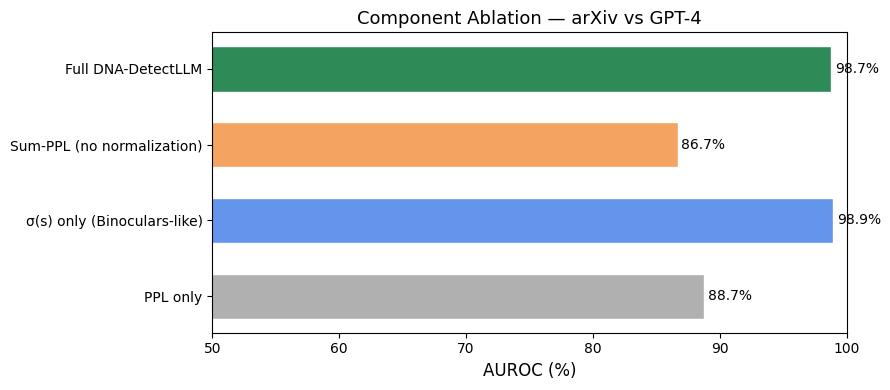

In [20]:
# ablation bar chart
labels_bar = list(variant_names.values())
aurocs_bar = [ablation_results[k]["auroc"]*100 for k in variant_names]
colors = ['#b0b0b0', '#6495ed', '#f4a460', '#2e8b57']

plt.figure(figsize=(9, 4))
plt.barh(labels_bar, aurocs_bar, color=colors, edgecolor='white', height=0.6)
plt.xlabel('AUROC (%)', fontsize=12)
plt.title('Component Ablation — arXiv vs GPT-4', fontsize=13)
plt.xlim(50, 100)
for i, v in enumerate(aurocs_bar):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## Temperature Sensitivity

The paper uses $T=1.0$. The `metrics.py` functions already accept a `temperature` parameter.

In [21]:
@torch.inference_mode()
def dna_score_at_temp(text, temperature=1.0):
    encodings, obs_logits, perf_logits = get_logits_and_encodings(text)
    pad_id = detector.tokenizer.pad_token_id
    spl = sum_perplexity(encodings, perf_logits, temperature=temperature)
    xpl = entropy(obs_logits, perf_logits, encodings, pad_id, temperature=temperature)
    return float(spl[0] / (2 * xpl[0]))

N_TEMP = 100
h_temp = load_texts("data/arxiv_human.json")[:N_TEMP]
a_temp = load_texts("data/gpt4_machine.json")[:N_TEMP]
all_temp = h_temp + a_temp

temperatures = [0.5, 0.8, 1.0, 1.5, 2.0]
temp_results = {}

for temp in temperatures:
    print(f"Temperature = {temp}")
    scores = []
    for text in tqdm(all_temp, desc=f"T={temp}"):
        try:
            scores.append(dna_score_at_temp(text, temperature=temp))
        except:
            scores.append(float('nan'))
    auroc, _ = eval_scores(scores, N_TEMP)
    temp_results[temp] = {"auroc": auroc, "scores": scores}
    print(f"  AUROC: {auroc*100:.2f}%\n")

Temperature = 0.5


T=0.5: 100%|██████████| 200/200 [06:12<00:00,  1.86s/it]


  AUROC: 91.72%

Temperature = 0.8


T=0.8: 100%|██████████| 200/200 [06:13<00:00,  1.87s/it]


  AUROC: 98.21%

Temperature = 1.0


...

  AUROC: 98.71%

Temperature = 1.5


T=1.5: 100%|██████████| 200/200 [06:12<00:00,  1.86s/it]


  AUROC: 97.56%

Temperature = 2.0


T=2.0: 100%|██████████| 200/200 [06:12<00:00,  1.86s/it]

  AUROC: 93.23%



TEMPERATURE SENSITIVITY
 Temperature      AUROC
-------------------------
         0.5     91.72%
         0.8     98.21%
         1.0     98.71% <-- default
         1.5     97.56%
         2.0     93.23%


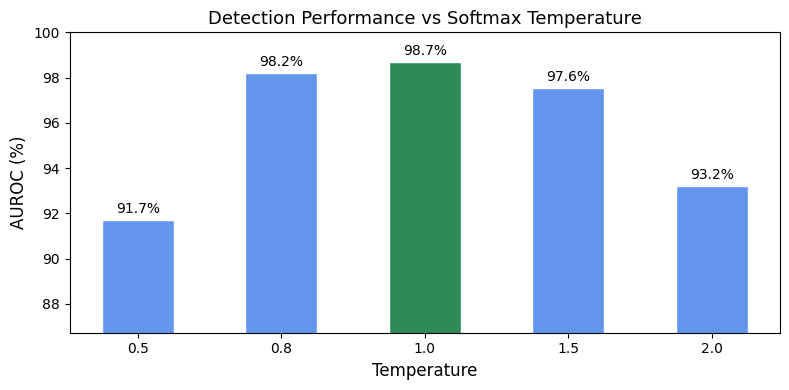

In [22]:
print("TEMPERATURE SENSITIVITY")
print(f"{'Temperature':>12} {'AUROC':>10}")
print("-" * 25)
for temp in temperatures:
    tag = " <-- default" if temp == 1.0 else ""
    print(f"{temp:>12.1f} {temp_results[temp]['auroc']*100:>9.2f}%{tag}")

aurocs_t = [temp_results[t]["auroc"]*100 for t in temperatures]
bar_colors = ['#2e8b57' if t == 1.0 else '#6495ed' for t in temperatures]

plt.figure(figsize=(8, 4))
plt.bar([str(t) for t in temperatures], aurocs_t, color=bar_colors, edgecolor='white', width=0.5)
plt.xlabel('Temperature', fontsize=12)
plt.ylabel('AUROC (%)', fontsize=12)
plt.title('Detection Performance vs Softmax Temperature', fontsize=13)
plt.ylim(max(0, min(aurocs_t) - 5), 100)
for i, v in enumerate(aurocs_t):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

## Short Text Robustness

How does detection degrade with fewer tokens?

In [23]:
N_LEN = 80
h_len = load_texts("data/arxiv_human.json")[:N_LEN]
a_len = load_texts("data/gpt4_machine.json")[:N_LEN]
all_len = h_len + a_len

lengths = [40, 80, 120, 200, 512]
length_results = {}
original_max = detector.max_token_observed

for max_len in lengths:
    print(f"Max length = {max_len} tokens")
    detector.max_token_observed = max_len
    scores = []
    for text in tqdm(all_len, desc=f"L={max_len}"):
        try:
            s = detector.compute_score(text)
            scores.append(s[0] if isinstance(s, list) else s)
        except:
            scores.append(float('nan'))

    valid = [s for s in scores if not np.isnan(s)]
    if len(valid) > 10:
        auroc, _ = eval_scores(scores, N_LEN)
    else:
        auroc = 0.5
    length_results[max_len] = {"auroc": auroc, "n_valid": len(valid)}
    print(f"  AUROC: {auroc*100:.2f}% ({len(valid)} valid)\n")

detector.max_token_observed = original_max

Max length = 40 tokens


L=40: 100%|██████████| 160/160 [02:16<00:00,  1.17it/s]


  AUROC: 82.21% (160 valid)

Max length = 80 tokens


L=80: 100%|██████████| 160/160 [02:56<00:00,  1.10s/it]


  AUROC: 89.10% (160 valid)

Max length = 120 tokens


...

  AUROC: 92.57% (160 valid)

Max length = 200 tokens


L=200: 100%|██████████| 160/160 [03:45<00:00,  1.41s/it]


  AUROC: 96.99% (160 valid)

Max length = 512 tokens


L=512: 100%|██████████| 160/160 [04:58<00:00,  1.87s/it]

  AUROC: 98.86% (160 valid)



SHORT TEXT PERFORMANCE
  Max Tokens      AUROC    Valid
-----------------------------------
          40     82.21%      160
          80     89.10%      160
         120     92.57%      160
         200     96.99%      160
         512     98.86%      160


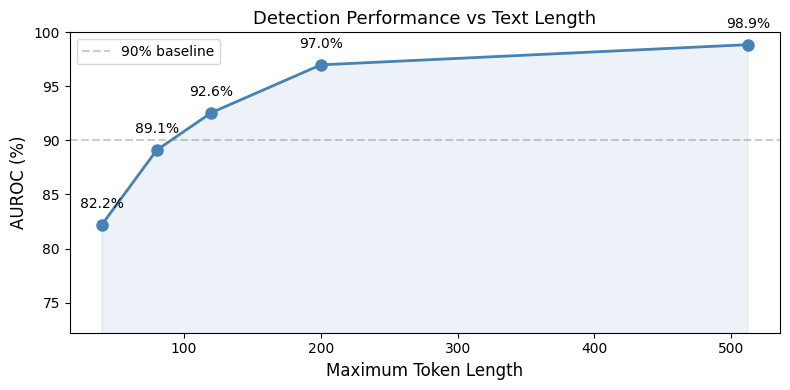

In [24]:
print("SHORT TEXT PERFORMANCE")
print(f"{'Max Tokens':>12} {'AUROC':>10} {'Valid':>8}")
print("-" * 35)
for l in lengths:
    r = length_results[l]
    print(f"{l:>12} {r['auroc']*100:>9.2f}% {r['n_valid']:>8}")

aurocs_l = [length_results[l]["auroc"]*100 for l in lengths]

plt.figure(figsize=(8, 4))
plt.plot(lengths, aurocs_l, 'o-', color='steelblue', lw=2, markersize=8)
plt.fill_between(lengths, aurocs_l, alpha=0.1, color='steelblue')
plt.xlabel('Maximum Token Length', fontsize=12)
plt.ylabel('AUROC (%)', fontsize=12)
plt.title('Detection Performance vs Text Length', fontsize=13)
plt.ylim(max(0, min(aurocs_l) - 10), 100)
for l, a in zip(lengths, aurocs_l):
    plt.annotate(f'{a:.1f}%', (l, a), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=10)
plt.axhline(y=90, color='gray', ls='--', alpha=0.4, label='90% baseline')
plt.legend()
plt.tight_layout()
plt.savefig('fig_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# save all results
output = {
    "table1": [{"name": r["name"], "auroc": r["auroc"], "f1": r["f1"], "speed": r["speed"]} for r in table1_results],
    "table2": [{"name": r["name"], "auroc": r["auroc"], "f1": r["f1"], "speed": r["speed"]} for r in table2_results],
    "repair_orders": {},
    "ablation": {k: {"auroc": v["auroc"], "f1": v["f1"]} for k, v in ablation_results.items()},
    "temperature": {str(t): {"auroc": r["auroc"]} for t, r in temp_results.items()},
    "length": {str(l): {"auroc": r["auroc"]} for l, r in length_results.items()},
}

for name, r in repair_results.items():
    h_sc = [s for s in r["scores"][:N_REPAIR] if not np.isnan(s)]
    a_sc = [s for s in r["scores"][N_REPAIR:] if not np.isnan(s)]
    auroc_val = roc_auc_score([1]*len(h_sc) + [0]*len(a_sc), h_sc + a_sc) if (h_sc and a_sc) else 0
    output["repair_orders"][name] = {"auroc": auroc_val, "time": r["time"]}

with open("all_results.json", "w") as f:
    json.dump(output, f, indent=2)
print("Saved all_results.json")

Saved all_results.json
